# Data audit: can we trust this dataset for fault detection?

This notebook checks the release before any modelling: do the files match the
published index, what do the units and raw-voltage channels mean, how often
did the bench log (and where did it skip), which channels are missing and
where, where each fault switches on, and which load bin each run falls in.
The findings drive the leakage and windowing rules used in every notebook
that follows.

**Main findings:** all 15 files match the published index in both row and
column counts (107,979 rows total: 51,893 Normal, 17,500 AC, 15,074 AF,
6,492 INJ, 9,174 CW, 7,846 TD). The bench does not log at a fixed 2 s: rows
step 1 s and 2 s alternately (about 1.6 s on average), and no run has a gap
over 4 s. `dPf` (Compressor Filter Loss) and `dPex` (Turbine Back Pressure)
are fully empty in four of the fourteen runs here (AC 85%, the one-hole
injector run and both cavitation runs) and in the lockbox run, exactly as the
release notes say; no other channel has a missing value. Every fixed-load run switches
on exactly once and stays faulty to the end (28 min to 111 min of healthy
data first); the injector run is faulty from its first row. Every
fixed-load run sits in its nominal load bin 100% of the time; the injector
and reference runs are stepped and span several bins by design.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from keyframe import audit, download, load, paths

paths.FIGURES.mkdir(parents=True, exist_ok=True)
paths.RESULTS.mkdir(parents=True, exist_ok=True)

## Do the files and row counts match the published index?

In [2]:
dataset_index = pd.read_csv(paths.RAW / "dataset_index.csv")
full_table = load.load_all(paths.RAW)

row_counts = dataset_index[~dataset_index["file_name"].str.endswith(download.LOCKBOX_FILE)].copy()
row_counts["run"] = row_counts["file_name"].str.split("/").str[-1].str.removesuffix(".csv")
row_counts["actual_rows"] = row_counts["run"].map(full_table.groupby("run").size())
row_counts["rows_match"] = row_counts["actual_rows"] == row_counts["data_rows"]
row_counts = row_counts[["run", "data_rows", "actual_rows", "rows_match", "columns"]]
row_counts.to_csv(paths.RESULTS / "00_row_counts.csv", index=False)
row_counts

,run,data_rows,actual_rows,rows_match,columns
0,Reference_Data,25302,25302,True,70
1,AC_Fouling_40_Load,4678,4678,True,73
2,AC_Fouling_60_Load,6698,6698,True,73
3,AC_Fouling_75_Load,6354,6354,True,73
4,AC_Fouling_85_Load,5801,5801,True,73
5,AF_Clogging_40_Load,4820,4820,True,73
6,AF_Clogging_60_Load,6819,6819,True,73
7,AF_Clogging_75_Load,5918,5918,True,73
8,AF_Clogging_85_Load,6398,6398,True,73
9,Clogged_Injector_Nozzle1_40_60_85_Load,6492,6492,True,73


## What units do the channels use, and which are raw voltages?

In [3]:
_, reference_columns = load.read_csv_with_header(paths.RAW / "Reference_Data.csv")
_, scenario_columns = load.read_csv_with_header(paths.RAW / "AC_Fouling" / "AC_Fouling_40_Load.csv")

raw_voltage_channels = scenario_columns.frame[scenario_columns.frame["is_raw_voltage"]]
raw_voltage_channels[["full_name", "symbol", "unit"]]

,full_name,symbol,unit
37,LO Circulating Pump Press.,Pl_lo,V
38,Fuel transfer pump Press.,Pl_fuel,V
39,Fresh Cooling Water Press.,Pl_water1,V
40,Sea Cooling Water Press.,Pl_water2,V
41,TCH LO pump Press.,Pl_loturb,V
42,Fuel Injector Cooling Oil Press.,Pl_valve,V


## How often did the bench log, and where does it skip?

The tech stack notes say sampling is not a fixed 2 s: time stamps step
alternately 1 s and 2 s (about 1.6 s on average). This section checks that
pattern and flags any gap over 4 s.

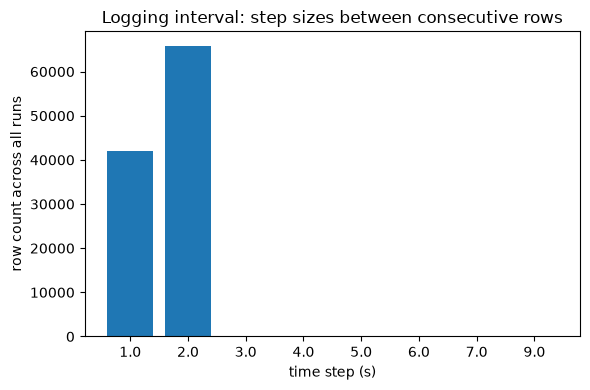

,run,max_gap_s,gaps_s
0,AC_Fouling_40_Load,3.0,[]
1,AC_Fouling_60_Load,2.0,[]
2,AC_Fouling_75_Load,3.0,[]
3,AC_Fouling_85_Load,3.0,[]
4,AF_Clogging_40_Load,5.0,[5.0]
5,AF_Clogging_60_Load,3.0,[]
6,AF_Clogging_75_Load,6.0,"[5.0, 6.0]"
7,AF_Clogging_85_Load,3.0,[]
8,Clogged_Injector_Nozzle1_40_60_85_Load,9.0,"[6.0, 7.0, 9.0]"
9,CW_Pump_Cavitation_60_Load,4.0,[]


In [4]:
intervals = audit.sampling_intervals(full_table)
step_values = sorted({round(v, 3) for counts in intervals["step_counts"] for v in counts})
step_totals = {v: sum(counts.get(v, 0) for counts in intervals["step_counts"]) for v in step_values}

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([str(v) for v in step_totals], step_totals.values())
ax.set_xlabel("time step (s)")
ax.set_ylabel("row count across all runs")
ax.set_title("Logging interval: step sizes between consecutive rows")
fig.tight_layout()
fig.savefig(paths.FIGURES / "00_sampling_intervals.png", dpi=150)
plt.show()

intervals[["run", "max_gap_s", "gaps_s"]]

## Which channels are missing, and where?

In [5]:
missing_channels = audit.missing_by_channel(full_table)
missing_channels.to_csv(paths.RESULTS / "00_missing_channels.csv", index=False)
missing_channels

,run,channel,missing_share
0,AC_Fouling_85_Load,Compressor Filter Loss,1.0
1,AC_Fouling_85_Load,Turbine Back Pressure,1.0
2,Clogged_Injector_Nozzle1_40_60_85_Load,Compressor Filter Loss,1.0
3,Clogged_Injector_Nozzle1_40_60_85_Load,Turbine Back Pressure,1.0
4,CW_Pump_Cavitation_60_Load,Compressor Filter Loss,1.0
5,CW_Pump_Cavitation_60_Load,Turbine Back Pressure,1.0
6,CW_Pump_Cavitation_85_Load,Compressor Filter Loss,1.0
7,CW_Pump_Cavitation_85_Load,Turbine Back Pressure,1.0


## Where does each fault switch on, and how long is each segment?

One row per scenario run: the first row where `Anomaly State` flips to 1,
and the healthy/faulty segment lengths either side of it. Injector runs
report no switch-on because they are faulty from the first row.

In [6]:
switch_on = audit.switch_on_points(full_table)
switch_on.to_csv(paths.RESULTS / "00_switch_on_points.csv", index=False)
switch_on

,run,row_index,t,Time_abs,healthy_rows,faulty_rows,healthy_minutes,faulty_minutes
0,AC_Fouling_40_Load,1218.0,2102.0,35567.0,1218,3460,35.033333,98.283333
1,AC_Fouling_60_Load,2057.0,3201.0,48597.0,2057,4641,53.350000,120.000000
2,AC_Fouling_75_Load,1665.0,2621.0,39325.0,1665,4689,43.683333,123.483333
3,AC_Fouling_85_Load,1091.0,1683.0,54936.0,1091,4710,28.050000,120.950000
4,AF_Clogging_40_Load,1690.0,2936.0,55779.0,1690,3130,48.933333,90.616667
5,AF_Clogging_60_Load,2095.0,3442.0,39137.0,2095,4724,57.366667,129.133333
6,AF_Clogging_75_Load,2368.0,3734.0,51012.0,2368,3550,62.233333,93.833333
7,AF_Clogging_85_Load,2728.0,4223.0,51605.0,2728,3670,70.383333,94.600000
8,Clogged_Injector_Nozzle1_40_60_85_Load,NaN,NaN,NaN,0,6492,0.000000,178.233333
9,CW_Pump_Cavitation_60_Load,1380.0,2251.0,36003.0,1380,4465,37.516667,121.133333


The figure below plots `Exh.Gas Temp. Turbine In` (a channel present in
every run and sensitive to all five fault types) for each fixed-load run,
with the switch-on point marked in red.

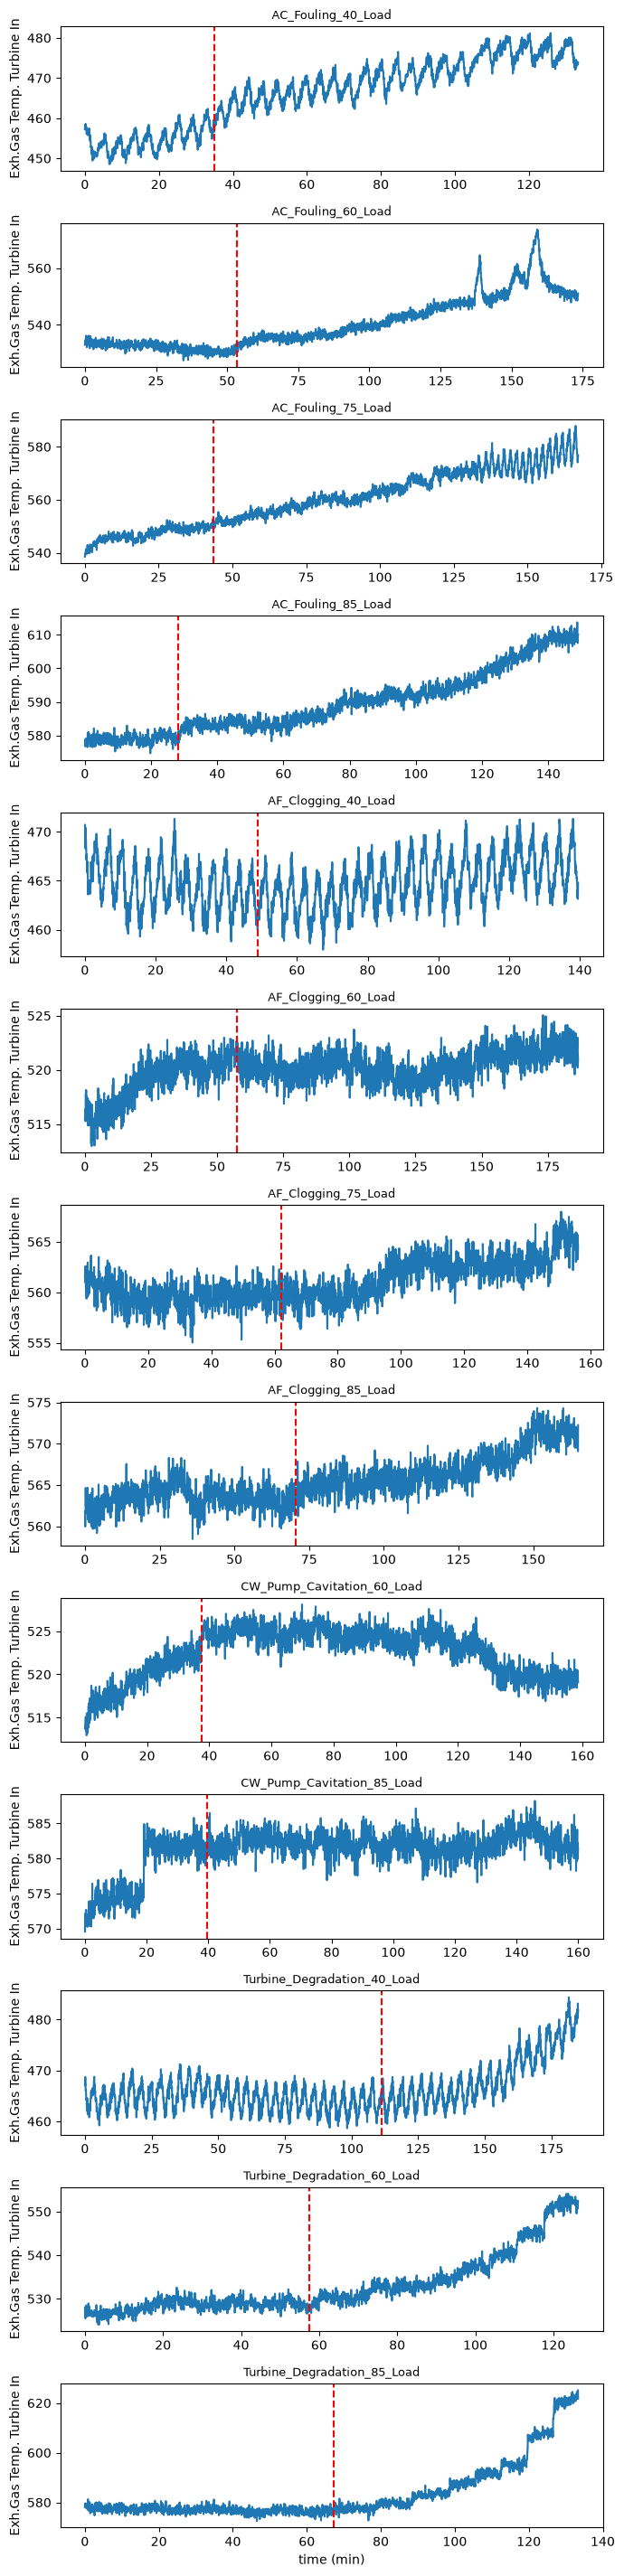

In [7]:
KEY_CHANNEL = "Exh.Gas Temp. Turbine In"

fixed_load_runs = full_table[["run", "nominal_load"]].drop_duplicates()
fixed_load_runs = fixed_load_runs[
    fixed_load_runs["nominal_load"].astype(str).str.match(audit._FIXED_LOAD)
]["run"].tolist()

switch_on_by_run = switch_on.set_index("run")
fig, axes = plt.subplots(len(fixed_load_runs), 1, figsize=(7, 2.2 * len(fixed_load_runs)))
for ax, run in zip(axes, fixed_load_runs, strict=True):
    group = full_table[full_table["run"] == run]
    ax.plot(group["t"] / 60.0, group[KEY_CHANNEL])
    if run in switch_on_by_run.index:
        t_switch = switch_on_by_run.loc[run, "t"]
        if pd.notna(t_switch):
            ax.axvline(t_switch / 60.0, color="red", linestyle="--")
    ax.set_ylabel(KEY_CHANNEL)
    ax.set_title(run, fontsize=9)
axes[-1].set_xlabel("time (min)")
fig.tight_layout()
fig.savefig(paths.FIGURES / "00_switch_on.png", dpi=150)
plt.show()

## Which load bin does each run fall in?

For fixed-load runs, the share of rows whose `load_bin` matches the
nominal load. Stepped runs and the reference file report row counts per
bin instead, since they cross several bins by design.

In [8]:
load_bins = audit.load_bin_agreement(full_table)
load_bins.to_csv(paths.RESULTS / "00_load_bins.csv", index=False)
load_bins

,run,fixed_load,agreement_share,bin_counts
0,AC_Fouling_40_Load,True,1.0,NaN
1,AC_Fouling_60_Load,True,1.0,NaN
2,AC_Fouling_75_Load,True,1.0,NaN
3,AC_Fouling_85_Load,True,1.0,NaN
4,AF_Clogging_40_Load,True,1.0,NaN
5,AF_Clogging_60_Load,True,1.0,NaN
6,AF_Clogging_75_Load,True,1.0,NaN
7,AF_Clogging_85_Load,True,1.0,NaN
8,Clogged_Injector_Nozzle1_40_60_85_Load,False,NaN,"{40: 1596, 60: 2338, 75: 61, 85: 2497}"
9,CW_Pump_Cavitation_60_Load,True,1.0,NaN


## Writing the clean table

In [9]:
clean_path = audit.write_clean_table(full_table)
clean_path

PosixPath('/home/user/KeyFrame/data/processed/clean.parquet')

## What this means for the next notebooks

- Row and column counts match the published index exactly, and the files
  we loaded are the ones the index describes: the table is trustworthy as
  a starting point.
- Sampling is not a fixed interval: rows step 1 s and 2 s alternately
  (about 1.6 s on average), with no gap over the 4 s threshold. Rolling
  windows are therefore defined in seconds of `t`, never in row counts,
  and are computed within one run.
- `dPf` and `dPex` are empty in five of the fifteen runs, and they are the
  very settings the researchers changed to create two of the faults. They
  are never model inputs: using them would be reading the answer, and their
  missing pattern alone gives away which file a row came from.
- Every fixed-load run switches on exactly once and stays faulty to the
  end; injector runs are faulty throughout. Splits must cut across whole
  runs, never inside a run, so no window straddles the healthy/faulty
  boundary or the train/test split.
- Every fixed-load run sits in its nominal load bin 100% of the time;
  stepped runs and the reference file span several bins by design and
  should be treated as multi-bin runs, not filtered out.
- The clean table at `data/processed/clean.parquet` keeps every channel;
  feature selection (dropping raw-voltage or fully-empty channels) happens
  later, at feature-engineering time, so this audit stays reusable.